# Análisis agregado

- Compromiso entre equidad y rendimiento.
- Comparación entre Fair-GAD y Fair-MAD.
- Comparación cuantitativa con la literatura, separando **detección**, **modelos estándar sin mitigar** y **técnicas que mitigan**.
- Aprendibilidad frente al predictor de clase mayoritaria.

**Requisito:** haber ejecutado antes los bucles de los seis conjuntos en los notebooks de detección, mitigación y baselines con la configuración definitiva (señal direccional en Fair-GAD y los parámetros de intensidad por conjunto).

El rendimiento se contrasta sobre la **exactitud y la F1 macro** de forma conjunta. Ambas magnitudes no se mueven en el mismo sentido en todos los conjuntos, por lo que el plano de compromiso tiene dos paneles y la condición de aprendibilidad se evalúa sobre la F1 macro, conservando la exactitud como magnitud reportada.

In [13]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score

from lamda.experiments import config as cfg
from lamda.experiments import runner

pd.set_option("display.float_format", "{:.4f}".format)

RESULTS_DIR = cfg.RESULTS_DIR
FIGURAS_DIR = os.path.join(RESULTS_DIR, "figuras")
os.makedirs(FIGURAS_DIR, exist_ok=True)

# =========================================================
# CONFIGURACIÓN: debe coincidir con la de detección y mitigación.
# =========================================================
TEST_SIZE = 0.2
RANDOM_STATE = 42
EXCLUIR_ATRIBUTO_SENSIBLE = False

## Carga de resultados persistidos

In [14]:
def load_csv(dataset, suffix):
    """Lee un CSV persistido por los notebooks anteriores, si existe."""
    path = os.path.join(RESULTS_DIR, f"{dataset}_{suffix}.csv")
    return pd.read_csv(path) if os.path.exists(path) else None


def columna(df, *candidatas):
    """
    Devuelve el primer nombre de columna presente entre las candidatas.

    Las tablas binarias y multiclase no comparten todos los nombres de columna,
    de modo que las celdas transversales deben resolver el nombre en tiempo de
    ejecución en lugar de asumirlo.
    """
    for c in candidatas:
        if c in df.columns:
            return c
    return None


deteccion, mitigacion, baselines_std = {}, {}, {}
for name in cfg.all_datasets():
    d = load_csv(name, "deteccion")
    m = load_csv(name, "mitigacion")
    b = load_csv(name, "baselines")
    if d is not None: deteccion[name] = d
    if m is not None: mitigacion[name] = m
    if b is not None: baselines_std[name] = b

print("Detección :", list(deteccion.keys()))
print("Mitigación:", list(mitigacion.keys()))
print("Baselines :", list(baselines_std.keys()))

faltan = [n for n in cfg.all_datasets() if n not in mitigacion]
if faltan:
    print("\nAVISO: faltan resultados de mitigación de", faltan,
          "\nEjecuta antes el bucle de los seis conjuntos en 5.2.")

Detección : ['adult', 'dutch', 'compas', 'oulad', 'communities', 'student']
Mitigación: ['adult', 'dutch', 'compas', 'oulad', 'communities', 'student']
Baselines : ['adult', 'dutch', 'compas', 'oulad', 'communities', 'student']


## Compromiso entre equidad y rendimiento

Cada punto es un par (conjunto, modelo). El eje horizontal recoge la disparidad agregada, donde menor es mejor, y el vertical el rendimiento, donde mayor es mejor, de modo que el comportamiento deseable se sitúa arriba a la izquierda.

Se representan **dos paneles con la misma escala de disparidad**: exactitud en el izquierdo y F1 macro en el derecho. La comparación entre ambos paneles es informativa por sí misma, ya que un desplazamiento hacia la izquierda que conserve la altura en el panel de exactitud pero la pierda en el de F1 macro indica que la reducción de disparidad no se obtiene sin coste, sino redistribuyendo aciertos entre clases.

In [15]:
# Panel completo de pares conjunto-modelo, con las dos magnitudes de rendimiento.
rows = []
for name, m in mitigacion.items():
    c_disp = columna(m, "mean_disparity")
    c_f1 = columna(m, "F1_macro", "f1_macro")
    for _, r in m.iterrows():
        rows.append({
            "Dataset": cfg.DATASETS[name].display_name,
            "Modelo": r["Modelo"],
            "Exactitud": float(r["Accuracy"]),
            "F1 macro": float(r[c_f1]) if c_f1 else np.nan,
            "Disparidad": float(r[c_disp]),
        })

tradeoff_df = pd.DataFrame(rows)
tradeoff_df

,Dataset,Modelo,Exactitud,F1 macro,Disparidad
0,Adult,LAMDA clásico,0.7654,0.7127,0.0780
1,Adult,Fair-GAD,0.7601,0.7034,0.0249
2,Adult,Fair-MAD,0.7598,0.7078,0.0641
3,Dutch Census,LAMDA clásico,0.7282,0.7282,0.0559
4,Dutch Census,Fair-GAD,0.7201,0.7197,0.0169
5,Dutch Census,Fair-MAD,0.7188,0.7185,0.0399
6,COMPAS,LAMDA clásico,0.6117,0.5985,0.2633
7,COMPAS,Fair-GAD,0.6117,0.5777,0.0859
8,COMPAS,Fair-MAD,0.6108,0.5971,0.2630
9,OULAD,LAMDA clásico,0.2871,0.2707,0.0920


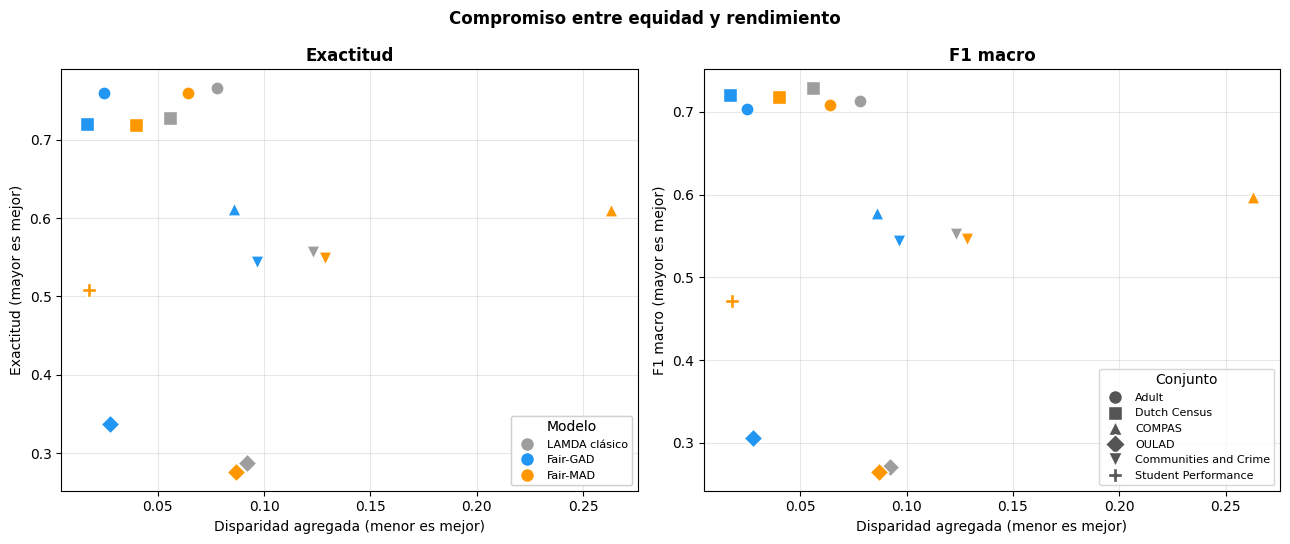

In [16]:
# ---------------------------------------------------------
# Plano disparidad-rendimiento en dos paneles.
# ---------------------------------------------------------
color_map = {"LAMDA clásico": "#9E9E9E", "Fair-GAD": "#2196F3", "Fair-MAD": "#FF9800"}
markers = ["o", "s", "^", "D", "v", "P"]
marker_map = {ds: markers[i % len(markers)]
              for i, ds in enumerate(tradeoff_df["Dataset"].unique())}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)

for ax, metrica in zip(axes, ["Exactitud", "F1 macro"]):
    for _, r in tradeoff_df.iterrows():
        ax.scatter(r["Disparidad"], r[metrica],
                   color=color_map.get(r["Modelo"], "#000"),
                   marker=marker_map[r["Dataset"]],
                   s=90, edgecolor="white", zorder=3)
    ax.set_xlabel("Disparidad agregada (menor es mejor)")
    ax.set_ylabel(f"{metrica} (mayor es mejor)")
    ax.set_title(metrica, fontweight="bold")
    ax.grid(alpha=0.3, zorder=0)

leg_models = [Line2D([0], [0], marker="o", color="w", markerfacecolor=v,
                     markersize=10, label=k) for k, v in color_map.items()]
leg_ds = [Line2D([0], [0], marker=v, color="w", markerfacecolor="#555",
                 markersize=10, label=k) for k, v in marker_map.items()]

l1 = axes[0].legend(handles=leg_models, title="Modelo", loc="lower right", fontsize=8)
axes[0].add_artist(l1)
axes[1].legend(handles=leg_ds, title="Conjunto", loc="lower right", fontsize=8)

fig.suptitle("Compromiso entre equidad y rendimiento", fontweight="bold")
fig.tight_layout()
plt.show()

In [17]:
# ---------------------------------------------------------
# Variación frente al LAMDA clásico.
# La reducción relativa permite comparar conjuntos cuya disparidad
# de partida es de magnitud muy distinta.
# ---------------------------------------------------------
tabla_rows = []
for name, m in mitigacion.items():
    mi = m.set_index("Modelo")
    if not all(k in mi.index for k in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]):
        print(f"AVISO: {name} no contiene los tres modelos; se omite.")
        continue

    c_disp = columna(m, "mean_disparity")
    c_f1 = columna(m, "F1_macro", "f1_macro")

    base_acc = float(mi.loc["LAMDA clásico", "Accuracy"])
    base_f1 = float(mi.loc["LAMDA clásico", c_f1])
    base_disp = float(mi.loc["LAMDA clásico", c_disp])

    for modelo in ["Fair-GAD", "Fair-MAD"]:
        acc = float(mi.loc[modelo, "Accuracy"])
        f1 = float(mi.loc[modelo, c_f1])
        disp = float(mi.loc[modelo, c_disp])
        # Con disparidad de partida nula no existe reducción relativa definida:
        # el conjunto carece de margen y así debe reportarse.
        reduccion = (base_disp - disp) / base_disp if base_disp > 0 else np.nan
        tabla_rows.append({
            "Dataset": cfg.DATASETS[name].display_name,
            "Modelo": modelo,
            "Δ Exactitud": acc - base_acc,
            "Δ F1 macro": f1 - base_f1,
            "Δ Disparidad": disp - base_disp,
            "Reducción relativa": reduccion,
            "Margen": "sí" if base_disp > 0 else "no",
        })

tabla_compromiso = pd.DataFrame(tabla_rows).set_index(["Dataset", "Modelo"])
tabla_compromiso.to_csv(os.path.join(RESULTS_DIR, "compromiso.csv"))
tabla_compromiso

Δ Exactitud  Δ F1 macro  Δ Disparidad  \
Dataset               Modelo                                            
Adult                 Fair-GAD      -0.0053     -0.0093       -0.0531   
                      Fair-MAD      -0.0056     -0.0049       -0.0139   
Dutch Census          Fair-GAD      -0.0081     -0.0084       -0.0390   
                      Fair-MAD      -0.0094     -0.0097       -0.0160   
COMPAS                Fair-GAD       0.0000     -0.0208       -0.1774   
                      Fair-MAD      -0.0009     -0.0014       -0.0003   
OULAD                 Fair-GAD       0.0503      0.0349       -0.0643   
                      Fair-MAD      -0.0106     -0.0052       -0.0051   
Communities and Crime Fair-GAD      -0.0125     -0.0091       -0.0265   
                      Fair-MAD      -0.0075     -0.0060        0.0055   
Student Performance   Fair-GAD       0.0000      0.0000        0.0000   
                      Fair-MAD       0.0000      0.0000        0.0000   

                                Reducción relativa Margen  
Dataset               Modelo                               
Adult                 Fair-GAD              0.6804     sí  
                      Fair-MAD              0.1785     sí  
Dutch Census          Fair-GAD              0.6976     sí  
                      Fair-MAD              0.2867     sí  
COMPAS                Fair-GAD              0.6737     sí  
                      Fair-MAD              0.0012     sí  
OULAD                 Fair-GAD              0.6993     sí  
                      Fair-MAD              0.0550     sí  
Communities and Crime Fair-GAD              0.2153     sí  
                      Fair-MAD             -0.0445     sí  
Student Performance   Fair-GAD              0.0000     sí  
                      Fair-MAD              0.0000     sí

## Comparación entre Fair-GAD y Fair-MAD

Para cada conjunto, cuánto reduce cada propuesta la disparidad agregada respecto del modelo clásico y a qué coste en rendimiento.

In [18]:
# ---------------------------------------------------------
# Reducción relativa comparada de las dos propuestas.
# ---------------------------------------------------------
tabla_reduccion = (tabla_compromiso
             .reset_index()
             .pivot(index="Dataset", columns="Modelo", values="Reducción relativa"))
tabla_reduccion["Diferencia (GAD − MAD)"] = tabla_reduccion["Fair-GAD"] - tabla_reduccion["Fair-MAD"]
tabla_reduccion.to_csv(os.path.join(RESULTS_DIR, "reduccion_relativa.csv"))
tabla_reduccion

Modelo,Fair-GAD,Fair-MAD,Diferencia (GAD − MAD)
Dataset,,,
Adult,0.6804,0.1785,0.5020
COMPAS,0.6737,0.0012,0.6724
Communities and Crime,0.2153,-0.0445,0.2598
Dutch Census,0.6976,0.2867,0.4109
OULAD,0.6993,0.0550,0.6443
Student Performance,0.0000,0.0000,0.0000


In [19]:
# ---------------------------------------------------------
# Desglose por métrica individual. Se resuelve el nombre de cada
# columna en tiempo de ejecución porque las tablas binarias y
# multiclase no comparten toda la nomenclatura.
# ---------------------------------------------------------
desglose_rows = []
for name, m in mitigacion.items():
    mi = m.set_index("Modelo")
    if not all(k in mi.index for k in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]):
        continue

    metricas = {
        "SPD": columna(m, "mean_abs_spd", "mean_spd_multiclass", "spd_multiclass"),
        "EOD": columna(m, "mean_abs_eod", "mean_eod_multiclass"),
        "DI mínimo": columna(m, "min_di", "min_di_sym"),
        "MEO": columna(m, "meo", "max_equal_opportunity"),
    }

    for modelo in ["Fair-GAD", "Fair-MAD"]:
        fila = {"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo}
        for etiqueta, col in metricas.items():
            if col is None:
                fila[f"Δ {etiqueta}"] = np.nan
                continue
            fila[f"Δ {etiqueta}"] = (float(mi.loc[modelo, col])
                                     - float(mi.loc["LAMDA clásico", col]))
        desglose_rows.append(fila)

desglose_metricas = pd.DataFrame(desglose_rows).set_index(["Dataset", "Modelo"])
desglose_metricas.to_csv(os.path.join(RESULTS_DIR, "desglose_metricas.csv"))
desglose_metricas

Δ SPD   Δ EOD  Δ DI mínimo  Δ MEO
Dataset               Modelo                                      
Adult                 Fair-GAD -0.0685 -0.0622       0.1531    NaN
                      Fair-MAD -0.0144 -0.0197       0.0400    NaN
Dutch Census          Fair-GAD -0.0471 -0.0215       0.0648    NaN
                      Fair-MAD -0.0200 -0.0165       0.0206    NaN
COMPAS                Fair-GAD -0.1778 -0.1779       0.1851    NaN
                      Fair-MAD -0.0009 -0.0003      -0.0027    NaN
OULAD                 Fair-GAD -0.0832 -0.0845       0.1179    NaN
                      Fair-MAD -0.0026 -0.0066       0.0021    NaN
Communities and Crime Fair-GAD -0.0302  0.0029       0.0472    NaN
                      Fair-MAD  0.0033  0.0273      -0.0182    NaN
Student Performance   Fair-GAD  0.0000  0.0000       0.0000    NaN
                      Fair-MAD  0.0000  0.0000       0.0000    NaN

## Aprendibilidad: LAMDA frente al predictor de clase mayoritaria

Evidencia sobre las amenazas a la validez. La formulación del LAMDA clásico agrega los grados de adecuación marginal sin ponderar la frecuencia a priori de cada clase, por lo que su asignación por máximo grado de adecuación global es insensible a las tasas base.

**La firma empírica de esa insensibilidad no es una única cifra, sino la combinación de dos.** Un clasificador insensible a las tasas base reparte sus asignaciones entre las clases en lugar de concentrarlas en la mayoritaria, de modo que puede quedar **por debajo** del predictor trivial en exactitud y **por encima** en F1 macro. Ambas columnas deben reportarse juntas: la primera aislada sugeriría que el modelo no aprende, y la segunda aislada ocultaría el efecto del desbalance.

In [20]:
apr_rows = []
for name in cfg.all_datasets():
    if name not in deteccion:
        continue

    Xtr, Xte, ytr, yte, *_ = runner.load_and_split(
        name, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

    # Predictor trivial: asigna siempre la clase mayoritaria de entrenamiento.
    maj = Counter(np.asarray(ytr).tolist()).most_common(1)[0][0]
    y_trivial = np.full_like(np.asarray(yte), maj)
    acc_trivial = float((np.asarray(yte) == maj).mean())
    f1_trivial = float(f1_score(yte, y_trivial, average="macro", zero_division=0))

    d = deteccion[name]
    c_f1 = columna(d, "F1_macro", "f1_macro")
    acc_lamda = float(d.iloc[0]["Accuracy"])
    f1_lamda = float(d.iloc[0][c_f1])

    # Mejor estándar de baselines, si está disponible.
    mejor_estandar = np.nan
    if name in baselines_std:
        b = baselines_std[name].set_index("Modelo")
        b = b.drop(index="Clase mayoritaria", errors="ignore")
        if len(b):
            mejor_estandar = float(b["Accuracy"].max())

    apr_rows.append({
        "Dataset": cfg.DATASETS[name].display_name,
        "Exactitud LAMDA": acc_lamda,
        "Exactitud trivial": acc_trivial,
        "F1 macro LAMDA": f1_lamda,
        "F1 macro trivial": f1_trivial,
        "Mejor estándar (exactitud)": mejor_estandar,
        "Supera trivial (F1 macro)": f1_lamda > f1_trivial,
        # Firma de la insensibilidad a las tasas base.
        "Exactitud bajo trivial": acc_lamda < acc_trivial,
    })

aprendibilidad = pd.DataFrame(apr_rows).set_index("Dataset")
aprendibilidad.to_csv(os.path.join(RESULTS_DIR, "aprendibilidad_agregada.csv"))
aprendibilidad

,Exactitud LAMDA,Exactitud trivial,F1 macro LAMDA,F1 macro trivial,Mejor estándar (exactitud),Supera trivial (F1 macro),Exactitud bajo trivial
Dataset,,,,,,,
Adult,0.7654,0.7510,0.7127,0.4289,0.8470,True,False
Dutch Census,0.7282,0.5239,0.7282,0.3438,0.8361,True,False
COMPAS,0.6117,0.5294,0.5985,0.3461,0.6799,True,False
OULAD,0.2871,0.3757,0.2707,0.1366,0.4435,True,True
Communities and Crime,0.5564,0.3409,0.5530,0.1695,0.6942,True,False
Student Performance,0.5077,0.4615,0.4721,0.2105,0.6308,True,False


### Detección: disparidad de partida frente a la literatura

Referencia: **Le Quy et al. (2022)**, *A survey on datasets for fairness-aware machine learning*, WIREs DMKD 12(3) e1452, Tabla 15 (métricas calculadas por los autores con **regresión logística**).

In [21]:
# |SPD| de literatura VERIFICADO (Le Quy et al., 2022, Tabla 15). Solo binarios.
LIT_DETECCION = {
    "adult":  {"spd_abs": 0.0555, "attr": "sex",  "acc_lit": 0.7864},
    "dutch":  {"spd_abs": 0.3568, "attr": "sex",  "acc_lit": 0.8149},
    "compas": {"spd_abs": 0.3398, "attr": "race", "acc_lit": 0.6414},
}

rows = []
for name in cfg.all_datasets():
    if name not in deteccion:
        continue
    d = deteccion[name]
    r = d.iloc[0]
    c_spd = columna(d, "mean_abs_spd", "mean_spd_multiclass", "spd_multiclass")
    lit = LIT_DETECCION.get(name)
    rows.append({
        "Dataset": cfg.DATASETS[name].display_name,
        "Atributo": lit["attr"] if lit else cfg.DATASETS[name].sensitive_mode,
        "|SPD| LAMDA": float(r[c_spd]),
        "|SPD| literatura": lit["spd_abs"] if lit else np.nan,
        "Fuente": ("Le Quy et al. (2022), Tabla 15" if lit
                   else "sin comparable (versión multiclase)"),
    })

comparacion_deteccion = pd.DataFrame(rows).set_index("Dataset")
comparacion_deteccion.to_csv(os.path.join(RESULTS_DIR, "deteccion_literatura.csv"))
comparacion_deteccion

,Atributo,|SPD| LAMDA,|SPD| literatura,Fuente
Dataset,,,,
Adult,sex,0.1817,0.0555,"Le Quy et al. (2022), Tabla 15"
Dutch Census,sex,0.1724,0.3568,"Le Quy et al. (2022), Tabla 15"
COMPAS,race,0.3330,0.3398,"Le Quy et al. (2022), Tabla 15"
OULAD,gender,0.0280,NaN,sin comparable (versión multiclase)
Communities and Crime,black,0.2536,NaN,sin comparable (versión multiclase)
Student Performance,sex,0.0746,NaN,sin comparable (versión multiclase)


### Modelos de ML estándar sin mitigar


In [22]:
rows = []
for name in cfg.all_datasets():
    if name not in baselines_std:
        continue
    b = baselines_std[name].set_index("Modelo")
    c_spd_b = columna(baselines_std[name], "mean_abs_spd", "mean_spd_multiclass", "spd_multiclass")
    c_f1_b = columna(baselines_std[name], "F1_macro", "f1_macro")
    lit = LIT_DETECCION.get(name)

    for modelo in b.index:
        rows.append({"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo,
                     "Exactitud": float(b.loc[modelo, "Accuracy"]),
                     "F1 macro": float(b.loc[modelo, c_f1_b]) if c_f1_b else np.nan,
                     "|SPD|": float(b.loc[modelo, c_spd_b]) if c_spd_b else np.nan,
                     "Origen": "propio (misma partición)"})

    if name in deteccion:
        d = deteccion[name]
        r = d.iloc[0]
        c_spd_d = columna(d, "mean_abs_spd", "mean_spd_multiclass", "spd_multiclass")
        c_f1_d = columna(d, "F1_macro", "f1_macro")
        rows.append({"Dataset": cfg.DATASETS[name].display_name, "Modelo": "LAMDA clásico",
                     "Exactitud": float(r["Accuracy"]),
                     "F1 macro": float(r[c_f1_d]) if c_f1_d else np.nan,
                     "|SPD|": float(r[c_spd_d]),
                     "Origen": "propio (misma partición)"})

    if lit:
        rows.append({"Dataset": cfg.DATASETS[name].display_name,
                     "Modelo": "Regresión logística (Le Quy et al., 2022)",
                     "Exactitud": lit["acc_lit"], "F1 macro": np.nan,
                     "|SPD|": lit["spd_abs"],
                     "Origen": "literatura verificada"})

comparacion_estandar = pd.DataFrame(rows).set_index(["Dataset", "Modelo"])
comparacion_estandar.to_csv(os.path.join(RESULTS_DIR, "modelos_estandar.csv"))
comparacion_estandar

Exactitud  \
Dataset               Modelo                                                 
Adult                 LogisticRegression                            0.8437   
                      DecisionTree                                  0.8134   
                      RandomForest                                  0.8470   
                      Clase mayoritaria                             0.7510   
                      LAMDA clásico                                 0.7654   
                      Regresión logística (Le Quy et al., 2022)     0.7864   
Dutch Census          LogisticRegression                            0.8361   
                      DecisionTree                                  0.8196   
                      RandomForest                                  0.8301   
                      Clase mayoritaria                             0.5239   
                      LAMDA clásico                                 0.7282   
                      Regresión logística (Le Quy et al., 2022)     0.8149   
COMPAS                LogisticRegression                            0.6799   
                      DecisionTree                                  0.5881   
                      RandomForest                                  0.6117   
                      Clase mayoritaria                             0.5294   
                      LAMDA clásico                                 0.6117   
                      Regresión logística (Le Quy et al., 2022)     0.6414   
OULAD                 LogisticRegression                            0.4435   
                      DecisionTree                                  0.3419   
                      RandomForest                                  0.3913   
                      Clase mayoritaria                             0.3757   
                      LAMDA clásico                                 0.2871   
Communities and Crime LogisticRegression                            0.6942   
                      DecisionTree                                  0.6040   
                      RandomForest                                  0.6917   
                      Clase mayoritaria                             0.3409   
                      LAMDA clásico                                 0.5564   
Student Performance   LogisticRegression                            0.5692   
                      DecisionTree                                  0.5077   
                      RandomForest                                  0.6308   
                      Clase mayoritaria                             0.4615   
                      LAMDA clásico                                 0.5077   

                                                                 F1 macro  \
Dataset               Modelo                                                
Adult                 LogisticRegression                           0.7765   
                      DecisionTree                                 0.7474   
                      RandomForest                                 0.7871   
                      Clase mayoritaria                            0.4289   
                      LAMDA clásico                                0.7127   
                      Regresión logística (Le Quy et al., 2022)       NaN   
Dutch Census          LogisticRegression                           0.8354   
                      DecisionTree                                 0.8187   
                      RandomForest                                 0.8296   
                      Clase mayoritaria                            0.3438   
                      LAMDA clásico                                0.7282   
                      Regresión logística (Le Quy et al., 2022)       NaN   
COMPAS                LogisticRegression                           0.6748   
                      DecisionTree                                 0.5877   
                      RandomForest                                 0.6089   
                      Cla

### Técnicas de mitigación publicadas

In [23]:
# Cifras VERIFICADAS de mitigación publicada. Solo Adult (sex).
mitigacion_literatura = pd.DataFrame([
    {"Dataset": "Adult", "Atributo": "sex", "Técnica": "Reweighing (Kamiran & Calders, 2012)",
     "Métrica": "SPD", "Antes": -0.2021, "Después": -0.0119,
     "Fuente": "Bellamy et al. (2018), AIF360, ap. B.5", "Solidez": "salida de ejemplo"},
    {"Dataset": "Adult", "Atributo": "sex", "Técnica": "Reweighing (Kamiran & Calders, 2012)",
     "Métrica": "SPD", "Antes": -0.1977, "Después": 0.0000,
     "Fuente": "Tutorial AIF360", "Solidez": "salida de ejemplo"},
    {"Dataset": "Adult", "Atributo": "sex", "Técnica": "Reject Option (Kamiran et al.)",
     "Métrica": "Equal opportunity (EOD)", "Antes": 0.128, "Después": 0.043,
     "Fuente": "CDEI Bias Mitigation", "Solidez": "benchmark web"},
    {"Dataset": "Adult", "Atributo": "sex", "Técnica": "Adversarial Debiasing (Zhang et al.)",
     "Métrica": "Equal opportunity (EOD)", "Antes": 0.128, "Después": 0.094,
     "Fuente": "CDEI Bias Mitigation", "Solidez": "benchmark web"},
    {"Dataset": "Adult", "Atributo": "sex", "Técnica": "Reductions (Agarwal et al.)",
     "Métrica": "Equal opportunity (EOD)", "Antes": 0.128, "Después": 0.014,
     "Fuente": "CDEI Bias Mitigation", "Solidez": "benchmark web"},
]).set_index(["Dataset", "Técnica", "Métrica"])
mitigacion_literatura

Atributo  \
Dataset Técnica                              Métrica                            
Adult   Reweighing (Kamiran & Calders, 2012) SPD                          sex   
                                             SPD                          sex   
        Reject Option (Kamiran et al.)       Equal opportunity (EOD)      sex   
        Adversarial Debiasing (Zhang et al.) Equal opportunity (EOD)      sex   
        Reductions (Agarwal et al.)          Equal opportunity (EOD)      sex   

                                                                       Antes  \
Dataset Técnica                              Métrica                           
Adult   Reweighing (Kamiran & Calders, 2012) SPD                     -0.2021   
                                             SPD                     -0.1977   
        Reject Option (Kamiran et al.)       Equal opportunity (EOD)  0.1280   
        Adversarial Debiasing (Zhang et al.) Equal opportunity (EOD)  0.1280   
        Reductions (Agarwal et al.)          Equal opportunity (EOD)  0.1280   

                                                                      Después  \
Dataset Técnica                              Métrica                            
Adult   Reweighing (Kamiran & Calders, 2012) SPD                      -0.0119   
                                             SPD                       0.0000   
        Reject Option (Kamiran et al.)       Equal opportunity (EOD)   0.0430   
        Adversarial Debiasing (Zhang et al.) Equal opportunity (EOD)   0.0940   
        Reductions (Agarwal et al.)          Equal opportunity (EOD)   0.0140   

                                                                                                      Fuente  \
Dataset Técnica                              Métrica                                                           
Adult   Reweighing (Kamiran & Calders, 2012) SPD                      Bellamy et al. (2018), AIF360, ap. B.5   
                                             SPD                                             Tutorial AIF360   
        Reject Option (Kamiran et al.)       Equal opportunity (EOD)                    CDEI Bias Mitigation   
        Adversarial Debiasing (Zhang et al.) Equal opportunity (EOD)                    CDEI Bias Mitigation   
        Reductions (Agarwal et al.)          Equal opportunity (EOD)                    CDEI Bias Mitigation   

                                                                                Solidez  
Dataset Técnica                              Métrica                                     
Adult   Reweighing (Kamiran & Calders, 2012) SPD                      salida de ejemplo  
                                             SPD                      salida de ejemplo  
        Reject Option (Kamiran et al.)       Equal opportunity (EOD)      benchmark web  
        Adversarial Debiasing (Zhang et al.) Equal opportunity (EOD)      benchmark web  
        Reductions (Agarwal et al.)          Equal opportunity (EOD)      benchmark web